<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Missing_Data_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Codeblock K001: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#@title Codeblock K002: Load Master_Rockfall_2021.xlsx
import pandas as pd

file_path = "/content/drive/MyDrive/Masters_Colab_Data/Master_Rockfall_2021.xlsx"

df = pd.read_excel(file_path, index_col=False)

print(df.info())
print(f"\nRows loaded: {len(df)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8376 entries, 0 to 8375
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    8376 non-null   int64         
 1   Datetime              8376 non-null   datetime64[ns]
 2   Gap_Rockfall          5193 non-null   object        
 3   Gap_hours             258 non-null    float64       
 4   Rockfall_Volume       5193 non-null   float64       
 5   Volume_Error          5193 non-null   float64       
 6   Rockfall_Event_Count  5193 non-null   float64       
 7   Total_Rainfall        8376 non-null   float64       
 8   Air_Temp              8376 non-null   float64       
 9   Relative_Humidity     8376 non-null   float64       
 10  Hourly_Rainfall       8330 non-null   float64       
 11  Thermal_image_name    4071 non-null   object        
 12  TA                    4071 non-null   float64       
 13  Tmean             

In [3]:
#@title Codeblock K003: Drop unused variables
cols_to_drop = [
    "ID", "Total_Rainfall", "Thermal_image_name",
    "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean",
    "Ref_File", "Rockfall_Occurrence"
]

df = df.drop(columns=cols_to_drop)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Datetime', 'Gap_Rockfall', 'Gap_hours', 'Rockfall_Volume', 'Volume_Error', 'Rockfall_Event_Count', 'Air_Temp', 'Relative_Humidity', 'Hourly_Rainfall', 'TA', 'Tmean', 'Tmin', 'Tmax', 'Ref_Mean', 'Ref_Max', 'Ref_Min', 'Ref_Range', 'Ref_sd']


=== BEFORE FIXING ===


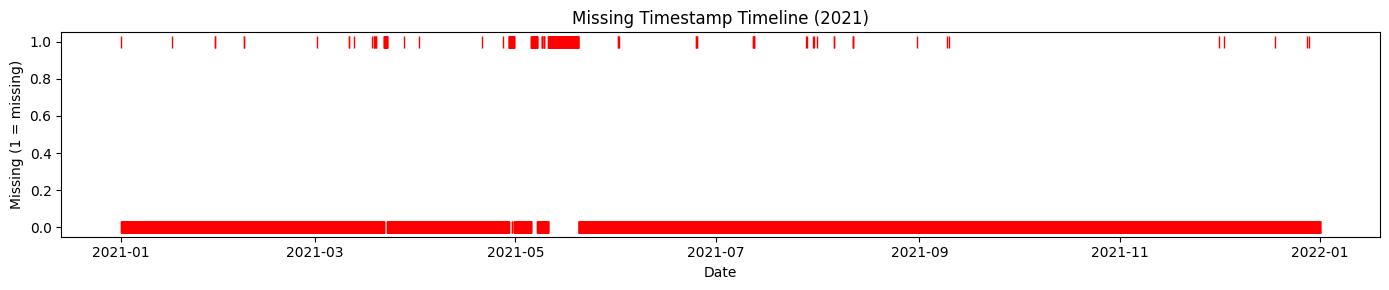

/tmp/ipykernel_17147/2752402403.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_missing = missing_df["Missing"].resample("M").sum()


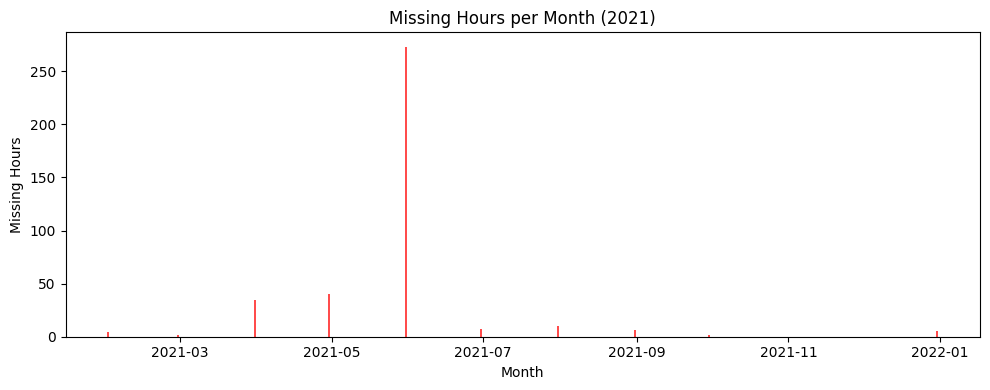

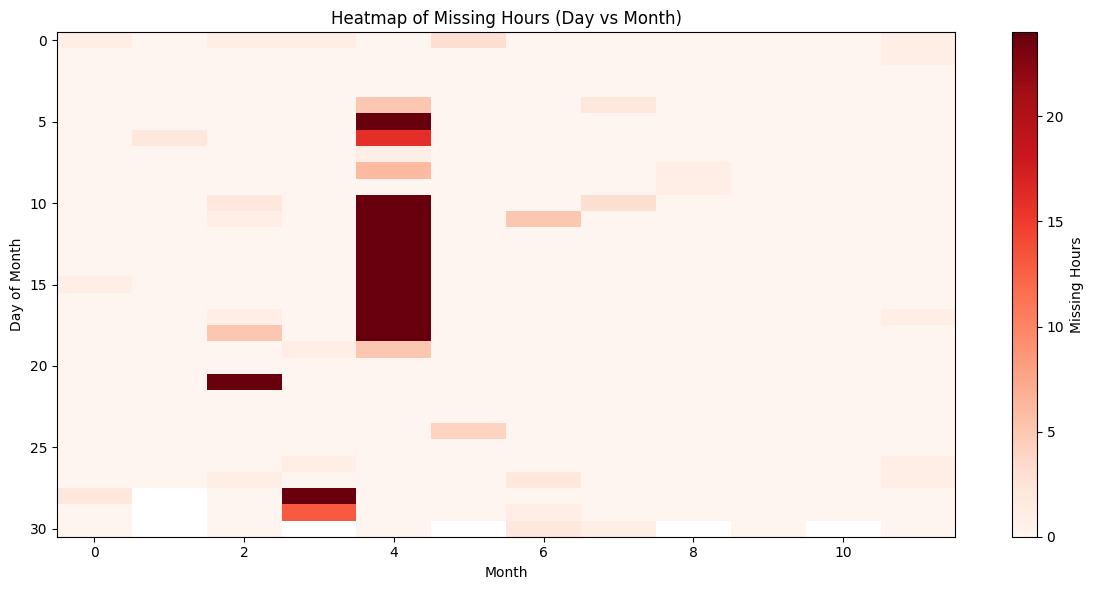

Missing timestamps before repair: 384

=== AFTER FIXING ===


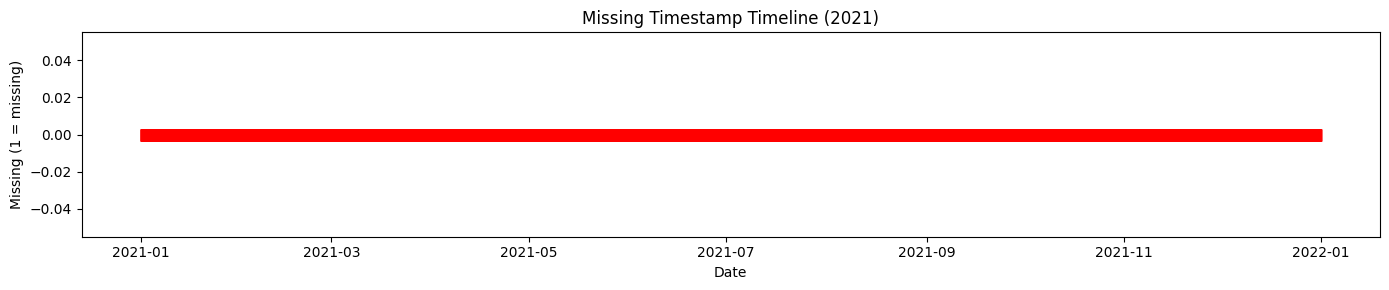

/tmp/ipykernel_17147/2752402403.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_missing = missing_df["Missing"].resample("M").sum()


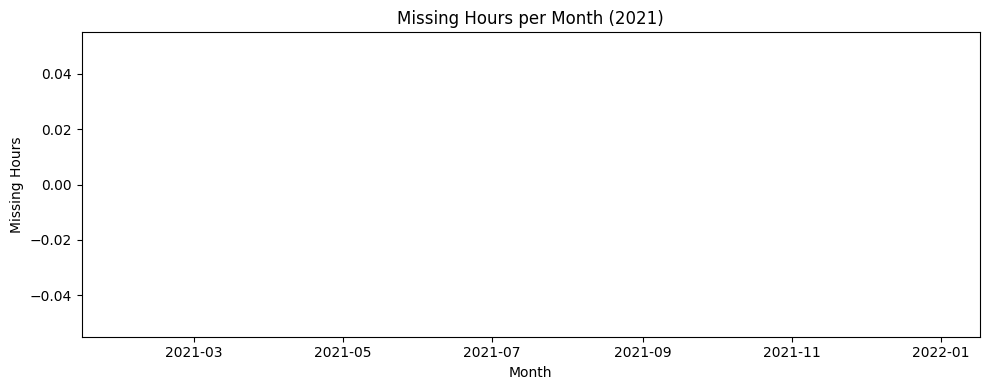

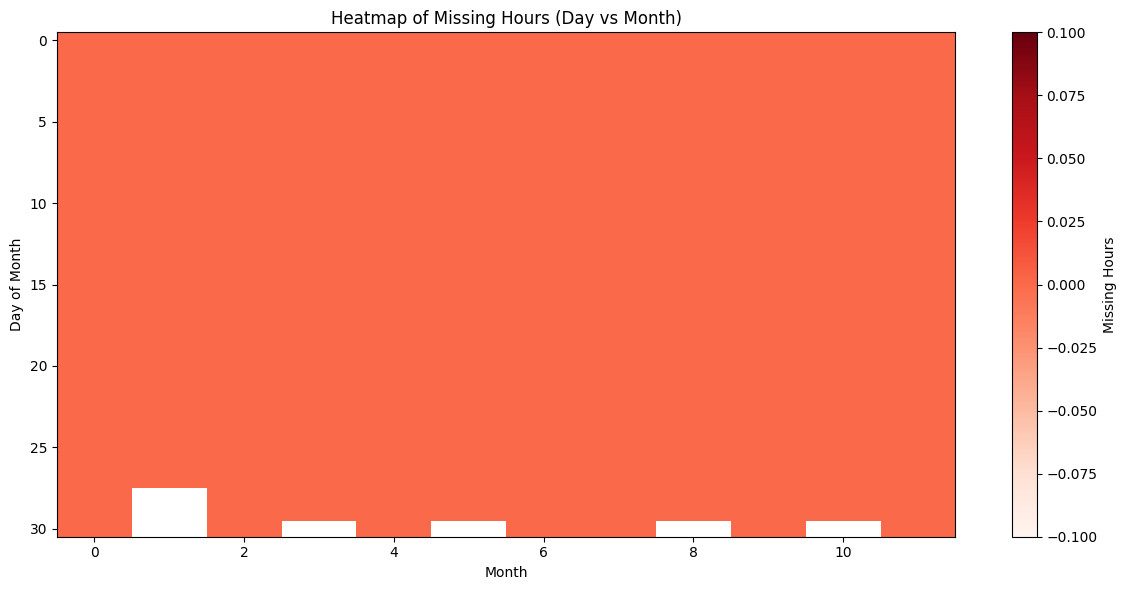

Missing timestamps after repair: 0

Timestamp repair complete. Dataframe now has full hourly coverage for 2021.


In [5]:
#@title Codeblock K013: Missing Timestamp Diagnostics + Auto-Repair

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

# Expected hourly timestamps for 2021
expected = pd.date_range(
    start="2021-01-01 00:00:00",
    end="2021-12-31 23:00:00",
    freq="h"
)

def plot_missing_timestamps(df, expected):
    """Plot timeline, monthly bars, and heatmap of missing timestamps."""
    actual = df["Datetime"]
    missing = expected.difference(actual)

    missing_df = pd.DataFrame(index=expected)
    missing_df["Missing"] = 0
    missing_df.loc[missing, "Missing"] = 1

    # --- Plot 1: Missing timeline ---
    plt.figure(figsize=(14, 3))
    plt.plot(
        missing_df.index,
        missing_df["Missing"],
        linestyle="none",
        marker="|",
        markersize=8,
        color="red"
    )
    plt.title("Missing Timestamp Timeline (2021)")
    plt.ylabel("Missing (1 = missing)")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Monthly missing counts ---
    monthly_missing = missing_df["Missing"].resample("M").sum()

    plt.figure(figsize=(10, 4))
    plt.bar(monthly_missing.index, monthly_missing.values, color="red", alpha=0.7)
    plt.title("Missing Hours per Month (2021)")
    plt.ylabel("Missing Hours")
    plt.xlabel("Month")
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Heatmap ---
    missing_df["Month"] = missing_df.index.month
    missing_df["Day"] = missing_df.index.day

    heatmap = missing_df.pivot_table(
        index="Day", columns="Month", values="Missing", aggfunc="sum"
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(heatmap, aspect="auto", cmap="Reds")
    plt.colorbar(label="Missing Hours")
    plt.title("Heatmap of Missing Hours (Day vs Month)")
    plt.xlabel("Month")
    plt.ylabel("Day of Month")
    plt.tight_layout()
    plt.show()

    return missing


# ---------------------------------------------------------
# 1. Plot BEFORE fixing
# ---------------------------------------------------------
print("=== BEFORE FIXING ===")
missing_before = plot_missing_timestamps(df, expected)
print(f"Missing timestamps before repair: {len(missing_before)}")


# ---------------------------------------------------------
# 2. Insert missing timestamps as empty rows
# ---------------------------------------------------------
df_full = pd.DataFrame(index=expected)
df_full.index.name = "Datetime"

# Merge original data into the full index
df = df.set_index("Datetime")
df_full = df_full.join(df)

# Reset index for consistency with your later code
df_full = df_full.reset_index()

# Replace original df with repaired version
df = df_full.copy()

# ---------------------------------------------------------
# 3. Plot AFTER fixing
# ---------------------------------------------------------
print("\n=== AFTER FIXING ===")
missing_after = plot_missing_timestamps(df, expected)
print(f"Missing timestamps after repair: {len(missing_after)}")

print("\nTimestamp repair complete. Dataframe now has full hourly coverage for 2021.")

In [ ]:
#@title Codeblock K003: Kalman Smoothing Diagnostics for Selected Variables

import pandas as pd
import numpy as np

# Variables to diagnose
vars_to_check = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

def largest_gap_info(series, time_index=None):
    """
    Returns:
        - largest gap length (count of consecutive NaNs)
        - start timestamp of gap (if datetime index provided)
        - end timestamp of gap
    """
    is_na = series.isna()

    # Identify consecutive NA groups
    gap_lengths = []
    gap_starts = []
    gap_ends = []

    in_gap = False
    start_idx = None

    for i, missing in enumerate(is_na):
        if missing and not in_gap:
            in_gap = True
            start_idx = i
        elif not missing and in_gap:
            in_gap = False
            gap_lengths.append(i - start_idx)
            gap_starts.append(start_idx)
            gap_ends.append(i - 1)

    # If the series ends in a gap
    if in_gap:
        gap_lengths.append(len(series) - start_idx)
        gap_starts.append(start_idx)
        gap_ends.append(len(series) - 1)

    if len(gap_lengths) == 0:
        return 0, None, None

    # Largest gap
    max_gap_idx = int(np.argmax(gap_lengths))
    gap_len = gap_lengths[max_gap_idx]
    start_i = gap_starts[max_gap_idx]
    end_i = gap_ends[max_gap_idx]

    if time_index is not None:
        return gap_len, time_index[start_i], time_index[end_i]
    else:
        return gap_len, start_i, end_i


# Ensure datetime index if available
time_index = None
if "Timestamp" in df.columns:
    try:
        time_index = pd.to_datetime(df["Timestamp"])
    except:
        time_index = None

diagnostics = []

for var in vars_to_check:
    if var not in df.columns:
        diagnostics.append({
            "Variable": var,
            "Exists": False,
            "First Obs NA": None,
            "Missing Count": None,
            "Largest Gap Length": None,
            "Gap Start": None,
            "Gap End": None
        })
        continue

    series = df[var]

    first_na = pd.isna(series.iloc[0])
    missing_count = series.isna().sum()

    gap_len, gap_start, gap_end = largest_gap_info(series, time_index)

    diagnostics.append({
        "Variable": var,
        "Exists": True,
        "First Obs NA": first_na,
        "Missing Count": missing_count,
        "Largest Gap Length": gap_len,
        "Gap Start": gap_start,
        "Gap End": gap_end
    })

diagnostics_df = pd.DataFrame(diagnostics)

print("Kalman-Relevant Missing Data Diagnostics:\n")
print(diagnostics_df)

Kalman-Relevant Missing Data Diagnostics:

             Variable  Exists  First Obs NA  Missing Count  \
0      Total_Rainfall    True          True            384   
1            Air_Temp    True          True            384   
2   Relative_Humidity    True          True            384   
3     Hourly_Rainfall    True          True            430   
4                  TA    True          True           4689   
5               Tmean    True          True           4689   
6                Tmin    True          True           4689   
7                Tmax    True          True           4689   
8           Tmeandiff    True          True           4689   
9            Tmindiff    True          True           4689   
10           Tmaxdiff    True          True           4689   
11       W1-BSS-Tmean    True          True           4689   
12      W2-IBSS-Tmean    True          True           4689   
13           Ref_Mean    True          True           3838   
14            Ref_Max    Tr

In [ ]:
#@title Codeblock K004: Variable Statistics + Physical Constraint Diagnostics

import pandas as pd
import numpy as np

vars_to_check = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

# Physical constraints
def count_physical_violations(var, series):
    if var == "Relative_Humidity":
        return ((series < 0) | (series > 100)).sum()
    if var in ["Hourly_Rainfall", "Total_Rainfall"]:
        return (series < 0).sum()
    return 0  # No constraint for other variables


# Largest gap finder
def largest_gap_info(series, time_index=None):
    is_na = series.isna()

    gap_lengths = []
    gap_starts = []
    gap_ends = []

    in_gap = False
    start_idx = None

    for i, missing in enumerate(is_na):
        if missing and not in_gap:
            in_gap = True
            start_idx = i
        elif not missing and in_gap:
            in_gap = False
            gap_lengths.append(i - start_idx)
            gap_starts.append(start_idx)
            gap_ends.append(i - 1)

    if in_gap:
        gap_lengths.append(len(series) - start_idx)
        gap_starts.append(start_idx)
        gap_ends.append(len(series) - 1)

    if len(gap_lengths) == 0:
        return 0, None, None

    max_gap_idx = int(np.argmax(gap_lengths))
    gap_len = gap_lengths[max_gap_idx]
    start_i = gap_starts[max_gap_idx]
    end_i = gap_ends[max_gap_idx]

    if time_index is not None:
        return gap_len, time_index[start_i], time_index[end_i]
    else:
        return gap_len, start_i, end_i


# Detect datetime index if available
time_index = None
if "Timestamp" in df.columns:
    try:
        time_index = pd.to_datetime(df["Timestamp"])
    except:
        time_index = None


# Build diagnostics table
rows = []

for var in vars_to_check:
    if var not in df.columns:
        rows.append({
            "Variable": var,
            "Exists": False,
            "Count": None,
            "Mean": None,
            "Std": None,
            "Min": None,
            "Max": None,
            "Physical Violations": None,
            "First Obs NA": None,
            "Missing Count": None,
            "Largest Gap Length": None,
            "Gap Start": None,
            "Gap End": None
        })
        continue

    series = df[var]

    # Basic stats
    count = series.count()
    mean = series.mean()
    std = series.std()
    min_val = series.min()
    max_val = series.max()

    # Physical constraint violations
    violations = count_physical_violations(var, series)

    # Missingness diagnostics
    first_na = pd.isna(series.iloc[0])
    missing_count = series.isna().sum()
    gap_len, gap_start, gap_end = largest_gap_info(series, time_index)

    rows.append({
        "Variable": var,
        "Exists": True,
        "Count": count,
        "Mean": mean,
        "Std": std,
        "Min": min_val,
        "Max": max_val,
        "Physical Violations": violations,
        "First Obs NA": first_na,
        "Missing Count": missing_count,
        "Largest Gap Length": gap_len,
        "Gap Start": gap_start,
        "Gap End": gap_end
    })

stats_df = pd.DataFrame(rows)

print("\nVariable Statistics + Physical Constraint Diagnostics:\n")
print(stats_df)


Variable Statistics + Physical Constraint Diagnostics:

             Variable  Exists  Count       Mean        Std        Min  \
0      Total_Rainfall    True   8376   1.228349   3.757940   0.000000   
1            Air_Temp    True   8376   9.721645   5.718376  -3.100000   
2   Relative_Humidity    True   8376  83.774391  10.287937  36.500000   
3     Hourly_Rainfall    True   8330   0.098451   0.527137   0.000000   
4                  TA    True   4071  10.156640   6.440294  -3.100000   
5               Tmean    True   4071   8.721680   7.751721  -8.659239   
6                Tmin    True   4071   5.521872   7.432781 -11.720000   
7                Tmax    True   4071  12.975574   8.988403  -5.070000   
8           Tmeandiff    True   4071  -1.434928   2.649165 -13.140000   
9            Tmindiff    True   4071  -4.634785   2.649476 -18.580000   
10           Tmaxdiff    True   4071   2.818929   3.634326  -5.080000   
11       W1-BSS-Tmean    True   4071   9.079255   7.158898  -7.5757

In [ ]:
#@title Codeblock K005: Prepare Kalman Imputation Columns

import pandas as pd
import numpy as np

vars_to_impute = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

# Ensure numeric dtype
for var in vars_to_impute:
    df[var] = pd.to_numeric(df[var], errors="coerce")

# Create Real + Kalman columns
for var in vars_to_impute:
    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    # 1 = real, 0 = missing/imputed
    df[real_col] = np.where(df[var].isna(), 0, 1)

    # Initialise Kalman column with original values (will be overwritten later)
    df[kalman_col] = df[var].copy()

print("Created _Real and _Kalman columns for all variables.")
df.head()

Created _Real and _Kalman columns for all variables.


,Datetime,ID,Gap_Rockfall,Gap_hours,Rockfall_Volume,Volume_Error,Rockfall_Event_Count,Total_Rainfall,Air_Temp,Relative_Humidity,...,Ref_Mean_Real,Ref_Mean_Kalman,Ref_Max_Real,Ref_Max_Kalman,Ref_Min_Real,Ref_Min_Kalman,Ref_Range_Real,Ref_Range_Kalman,Ref_sd_Real,Ref_sd_Kalman
0,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
1,2021-01-01 01:00:00,2.0,NoGap,NaN,0.0,0.0,0.0,0.00,4.1,88.9,...,1,-10.777718,1,-5.037747,1,-15.939015,1,10.901268,1,1.395919
2,2021-01-01 02:00:00,3.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.5,93.4,...,1,-10.970958,1,-5.366537,1,-15.783996,1,10.417459,1,1.396375
3,2021-01-01 03:00:00,4.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.8,93.7,...,1,-10.861423,1,-5.287881,1,-15.820294,1,10.532413,1,1.411564
4,2021-01-01 04:00:00,5.0,NaN,NaN,NaN,NaN,NaN,0.51,5.8,92.9,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [ ]:
#@title Codeblock K006: Kalman Smoothing Imputation With Physical Clipping

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents

vars_to_impute = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

def kalman_smooth_series(series):
    """
    Fits a local-level Kalman smoother to a single series.
    Returns the smoothed series.
    """
    model = UnobservedComponents(series, level="local level")
    result = model.fit(disp=False)
    smoothed = result.smoothed_state[0]  # local level component
    return pd.Series(smoothed, index=series.index)


for var in vars_to_impute:
    print(f"Processing {var}...")

    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    # Extract original series
    s = df[var].astype(float)

    # Compute observed min/max (ignoring NaNs)
    observed_min = s.min()
    observed_max = s.max()

    # Run Kalman smoother
    smoothed = kalman_smooth_series(s)

    # Clip to observed physical range
    smoothed_clipped = smoothed.clip(lower=observed_min, upper=observed_max)

    # Preserve real values, replace only missing ones
    df[kalman_col] = np.where(df[real_col] == 1, s, smoothed_clipped)

print("\nKalman smoothing imputation complete.")
df.head()

Processing Total_Rainfall...
Processing Air_Temp...
Processing Relative_Humidity...
Processing Hourly_Rainfall...
Processing TA...
Processing Tmean...
Processing Tmin...
Processing Tmax...
Processing Tmeandiff...
Processing Tmindiff...
Processing Tmaxdiff...
Processing W1-BSS-Tmean...
Processing W2-IBSS-Tmean...
Processing Ref_Mean...
Processing Ref_Max...
Processing Ref_Min...
Processing Ref_Range...
Processing Ref_sd...

Kalman smoothing imputation complete.


,Datetime,ID,Gap_Rockfall,Gap_hours,Rockfall_Volume,Volume_Error,Rockfall_Event_Count,Total_Rainfall,Air_Temp,Relative_Humidity,...,Ref_Mean_Real,Ref_Mean_Kalman,Ref_Max_Real,Ref_Max_Kalman,Ref_Min_Real,Ref_Min_Kalman,Ref_Range_Real,Ref_Range_Kalman,Ref_sd_Real,Ref_sd_Kalman
0,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,-10.828006,0,-5.147332,0,-15.924648,0,10.538749,0,1.395315
1,2021-01-01 01:00:00,2.0,NoGap,NaN,0.0,0.0,0.0,0.00,4.1,88.9,...,1,-10.777718,1,-5.037747,1,-15.939015,1,10.901268,1,1.395919
2,2021-01-01 02:00:00,3.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.5,93.4,...,1,-10.970958,1,-5.366537,1,-15.783996,1,10.417459,1,1.396375
3,2021-01-01 03:00:00,4.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.8,93.7,...,1,-10.861423,1,-5.287881,1,-15.820294,1,10.532413,1,1.411564
4,2021-01-01 04:00:00,5.0,NaN,NaN,NaN,NaN,NaN,0.51,5.8,92.9,...,0,-11.475970,0,-6.025399,0,-15.925658,0,9.886544,0,1.377043


In [ ]:
#@title Codeblock K010: Seasonal Kalman Smoothing with Data-Driven Q and R

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents

vars_to_impute = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

def estimate_Q(series):
    """State noise variance from first differences."""
    diffs = series.diff().dropna()
    return np.nanvar(diffs)

def estimate_R(series):
    """Observation noise variance from detrended residuals."""
    med = series.rolling(window=24, center=True, min_periods=1).median()
    residuals = series - med
    return np.nanvar(residuals)

def seasonal_kalman_smooth(series, Q, R, seasonal_period=24):
    """Seasonal + local level Kalman smoother with fixed Q and R."""
    model = UnobservedComponents(
        series,
        level="local level",
        seasonal=seasonal_period
    )

    # Fix parameters
    model.update(model.start_params)
    params = model.start_params.copy()

    # statsmodels parameter order:
    # [sigma2.irregular, sigma2.level, sigma2.seasonal]
    params[0] = R
    params[1] = Q
    params[2] = Q  # seasonal noise

    result = model.smooth(params)
    smoothed = result.smoothed_state[0]  # local level component
    return pd.Series(smoothed, index=series.index)

for var in vars_to_impute:
    print(f"Processing {var}...")

    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    s = df[var].astype(float)

    # Compute Q and R
    Q = estimate_Q(s)
    R = estimate_R(s)

    # Run seasonal Kalman smoother
    smoothed = seasonal_kalman_smooth(s, Q, R, seasonal_period=24)

    # Clip to observed range
    observed_min = s.min()
    observed_max = s.max()
    smoothed_clipped = smoothed.clip(lower=observed_min, upper=observed_max)

    # Replace missing values only
    df[kalman_col] = np.where(df[real_col] == 1, s, smoothed_clipped)

print("\nSeasonal Kalman smoothing complete.")
df.head()

Processing Total_Rainfall...
Processing Air_Temp...
Processing Relative_Humidity...
Processing Hourly_Rainfall...
Processing TA...
Processing Tmean...
Processing Tmin...
Processing Tmax...
Processing Tmeandiff...
Processing Tmindiff...
Processing Tmaxdiff...
Processing W1-BSS-Tmean...
Processing W2-IBSS-Tmean...
Processing Ref_Mean...
Processing Ref_Max...
Processing Ref_Min...
Processing Ref_Range...
Processing Ref_sd...

Seasonal Kalman smoothing complete.


,Datetime,ID,Gap_Rockfall,Gap_hours,Rockfall_Volume,Volume_Error,Rockfall_Event_Count,Total_Rainfall,Air_Temp,Relative_Humidity,...,Ref_Mean_Real,Ref_Mean_Kalman,Ref_Max_Real,Ref_Max_Kalman,Ref_Min_Real,Ref_Min_Kalman,Ref_Range_Real,Ref_Range_Kalman,Ref_sd_Real,Ref_sd_Kalman
0,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,-10.827581,0,-5.096783,0,-15.856456,0,10.796117,0,1.415608
1,2021-01-01 01:00:00,2.0,NoGap,NaN,0.0,0.0,0.0,0.00,4.1,88.9,...,1,-10.777718,1,-5.037747,1,-15.939015,1,10.901268,1,1.395919
2,2021-01-01 02:00:00,3.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.5,93.4,...,1,-10.970958,1,-5.366537,1,-15.783996,1,10.417459,1,1.396375
3,2021-01-01 03:00:00,4.0,NoGap,NaN,0.0,0.0,0.0,0.51,5.8,93.7,...,1,-10.861423,1,-5.287881,1,-15.820294,1,10.532413,1,1.411564
4,2021-01-01 04:00:00,5.0,NaN,NaN,NaN,NaN,NaN,0.51,5.8,92.9,...,0,-11.266552,0,-5.671825,0,-15.906023,0,10.243822,0,1.397996


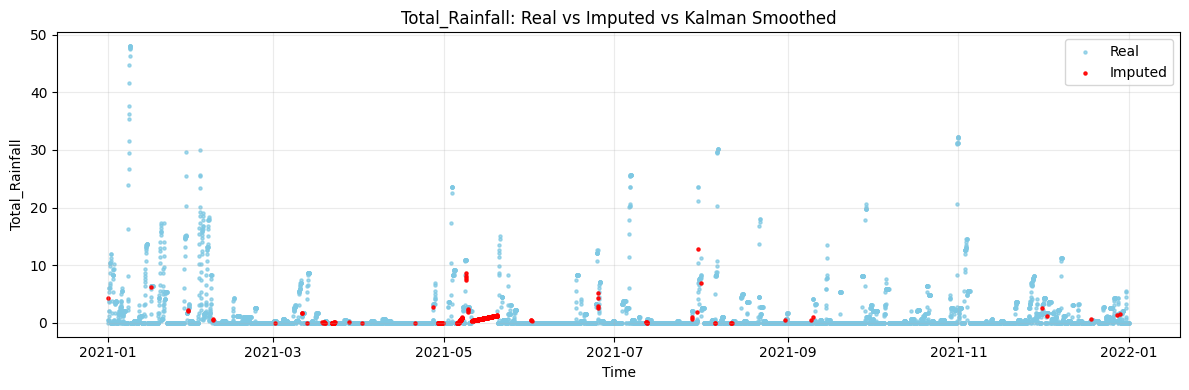

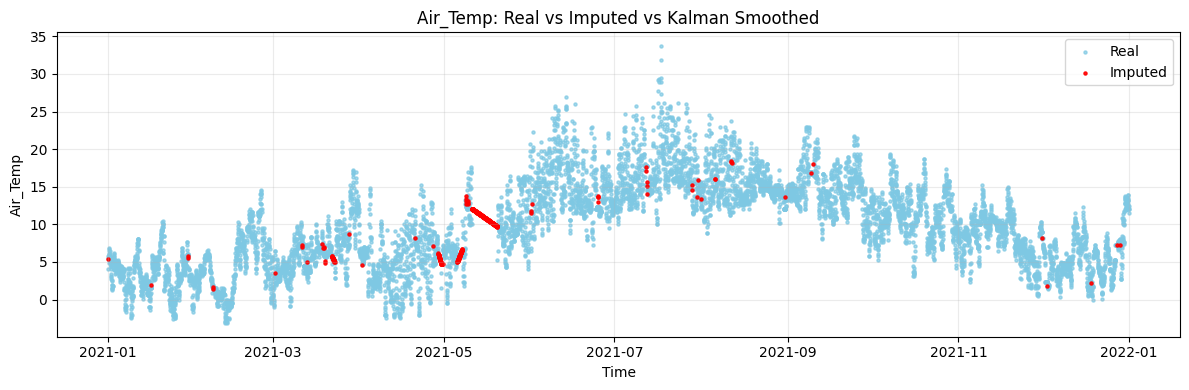

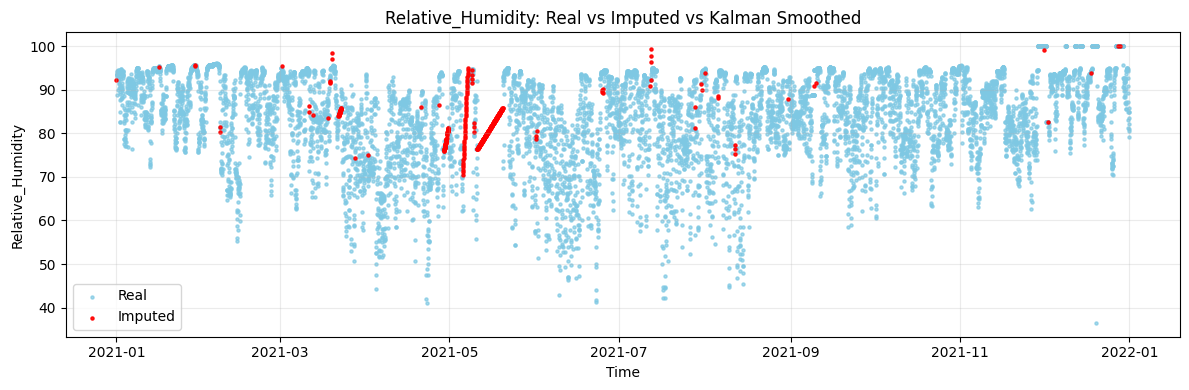

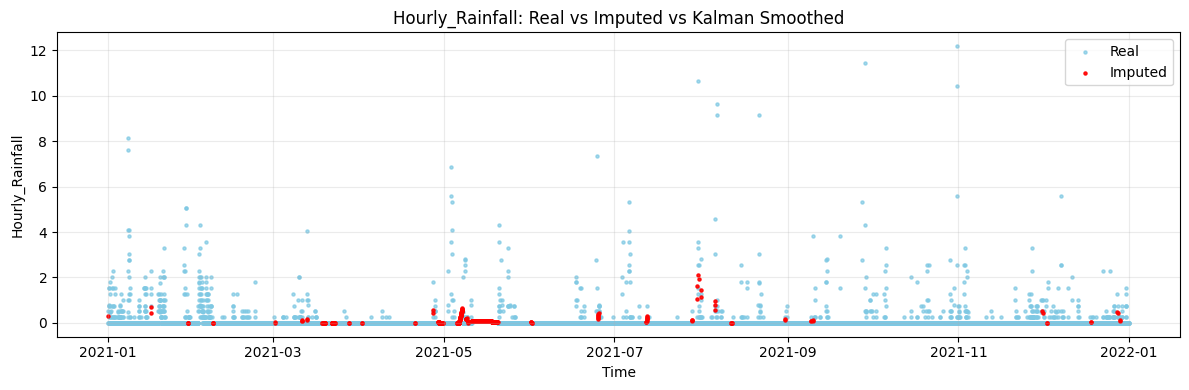

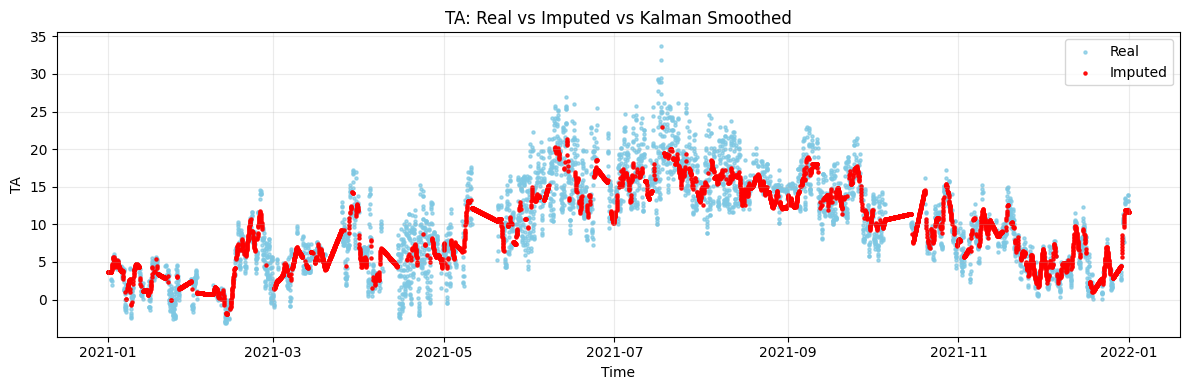

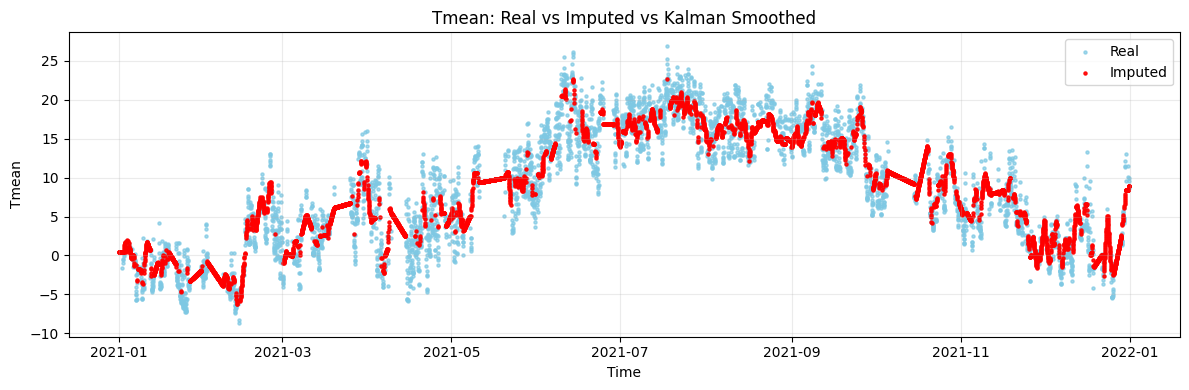

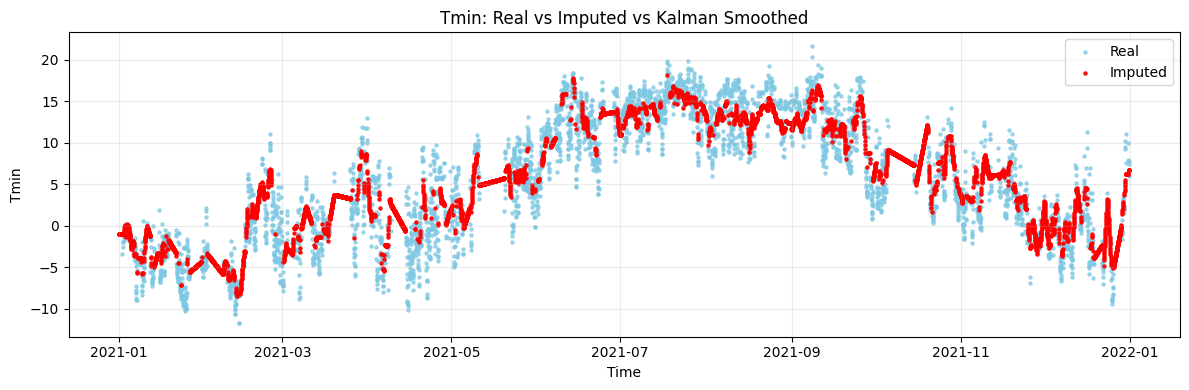

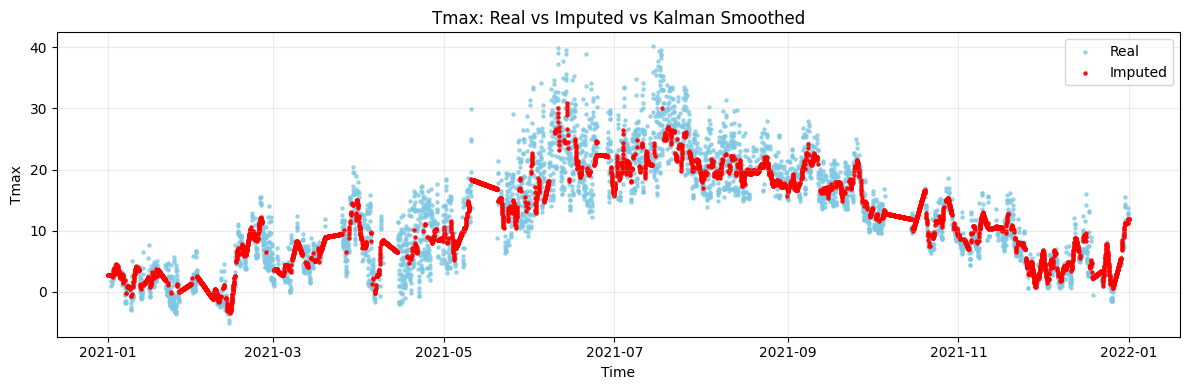

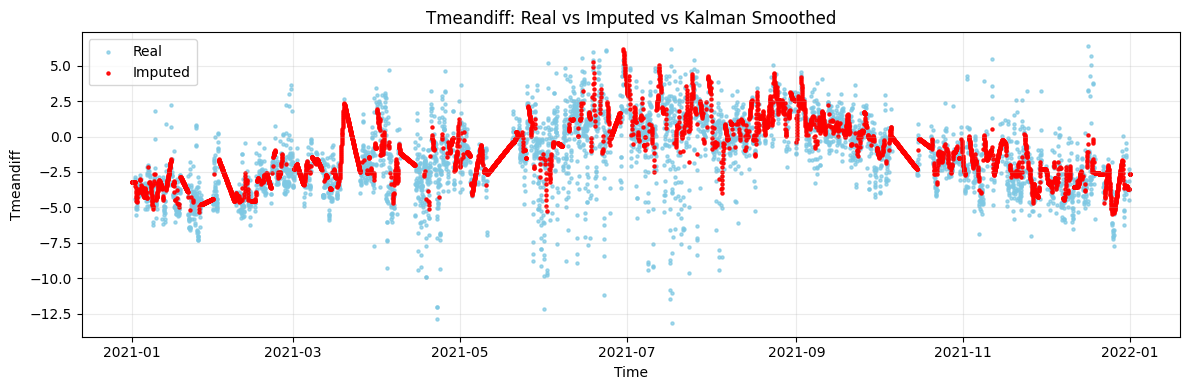

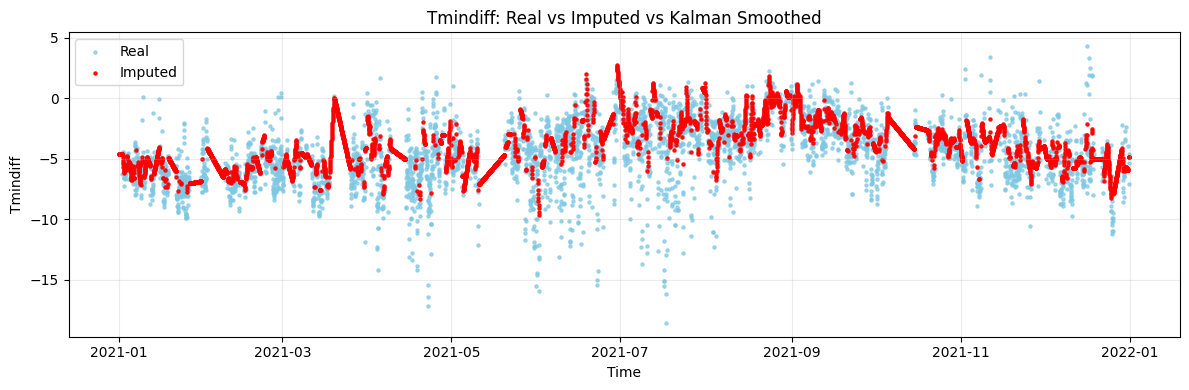

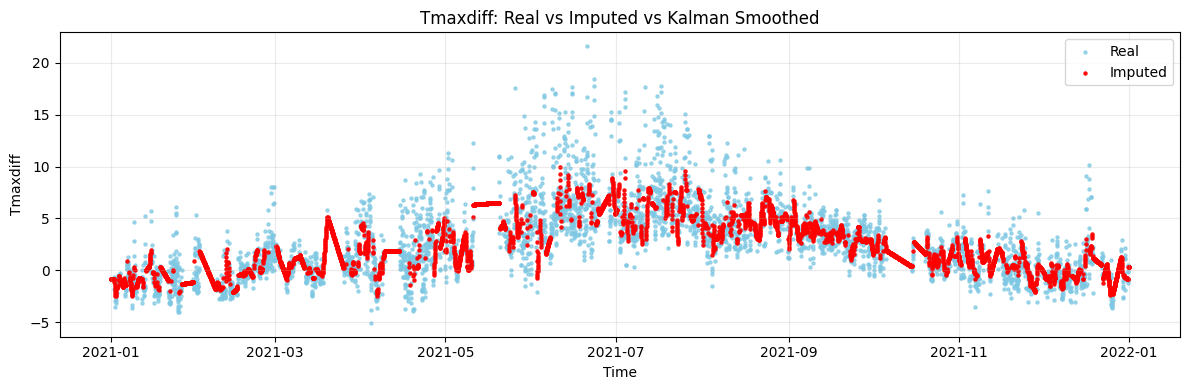

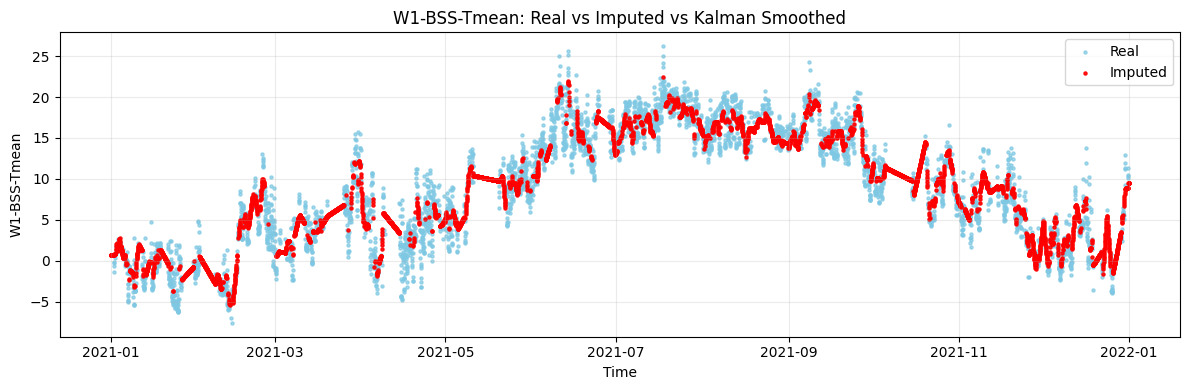

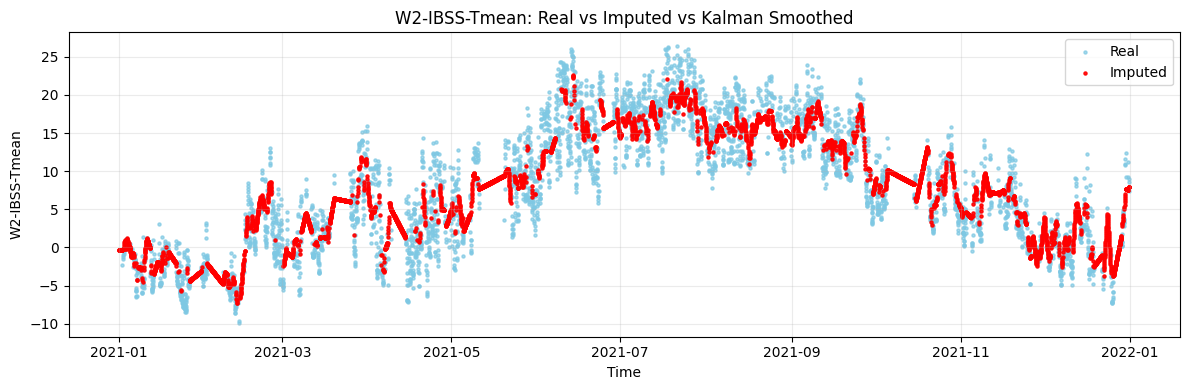

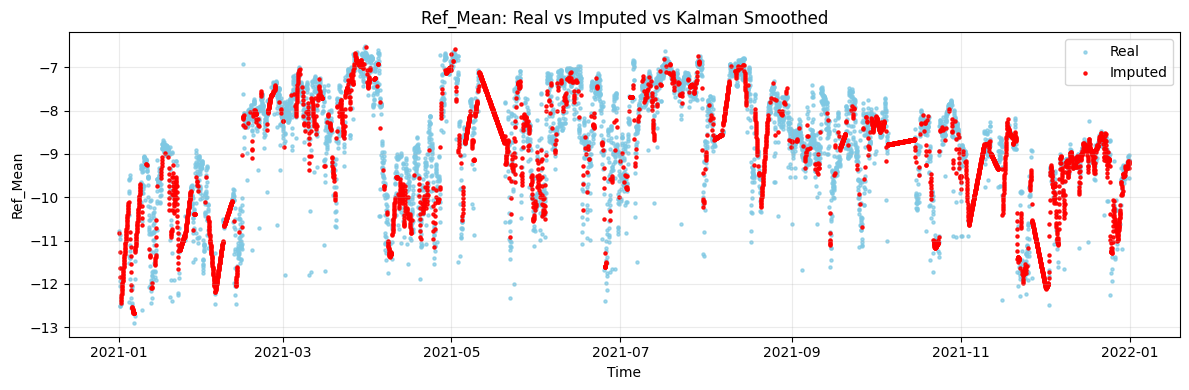

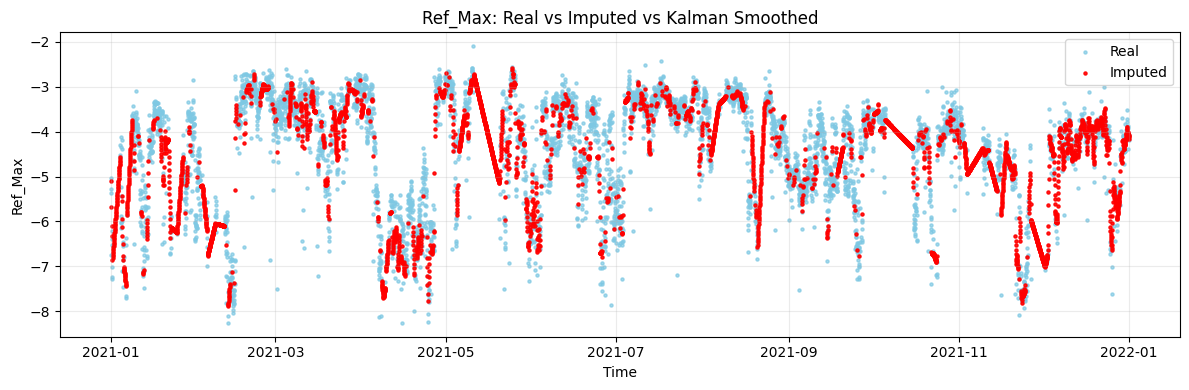

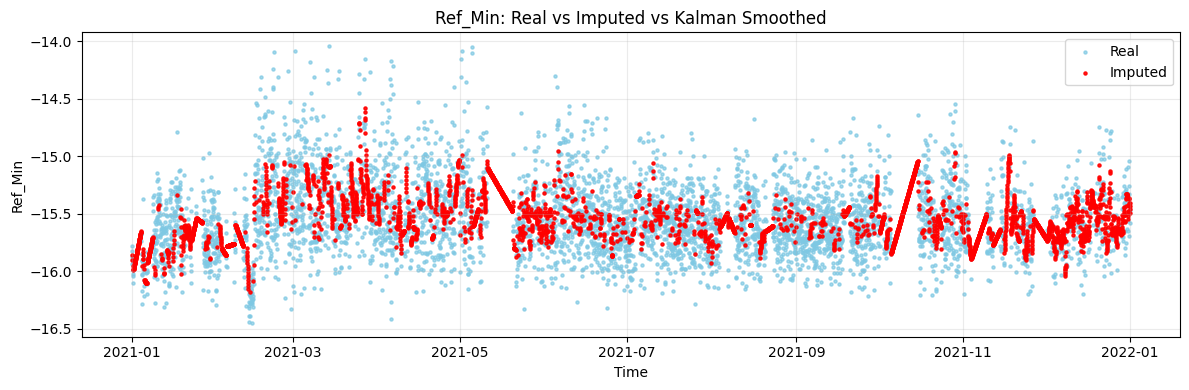

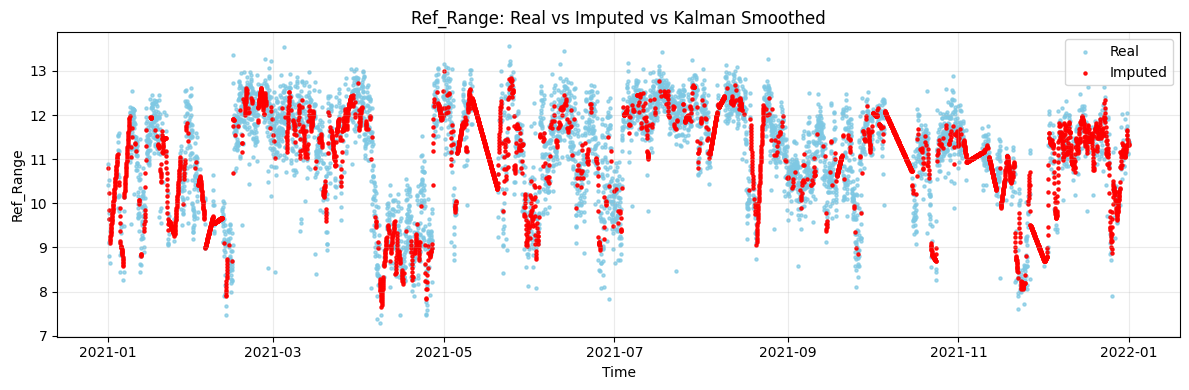

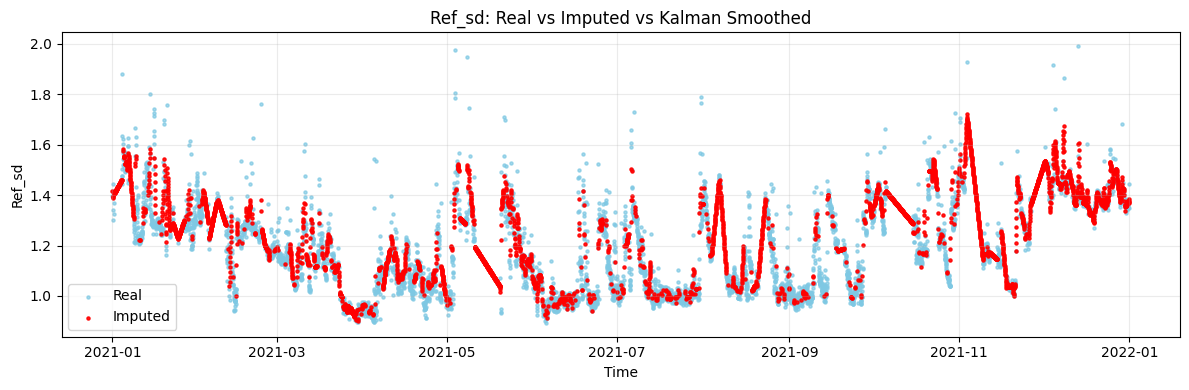

In [ ]:
#@title Codeblock K007 (Point Version): Real (Light Blue) vs Imputed (Red) vs Kalman (Blue)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

vars_to_impute = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

# Use Datetime if available
if "Datetime" in df.columns:
    x = pd.to_datetime(df["Datetime"])
else:
    x = df.index

for var in vars_to_impute:
    real_col = f"{var}_Real"
    kalman_col = f"{var}_Kalman"

    plt.figure(figsize=(12, 4))

    # Real values as faint light-blue points
    plt.scatter(
        x[df[real_col] == 1],
        df.loc[df[real_col] == 1, var],
        s=5,
        color="#7EC8E3",     # light blue
        alpha=0.7,
        label="Real"
    )

    # Imputed values as solid red points
    plt.scatter(
        x[df[real_col] == 0],
        df.loc[df[real_col] == 0, kalman_col],
        s=5,
        color="red",
        alpha=0.9,
        label="Imputed"
    )

    '''# Kalman smoothed trajectory (optional but useful)
      plt.plot(
        x,
        df[kalman_col],
        color="#252525",     # dark black
        linewidth=0.5,
        alpha=0.5,
        label="Kalman Smoothed"
    )
    '''

    plt.title(f"{var}: Real vs Imputed vs Kalman Smoothed")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [ ]:
#@title Codeblock K011: Missing & Imputed Value Diagnostics

import pandas as pd

vars_to_impute = [
    "Total_Rainfall", "Air_Temp", "Relative_Humidity", "Hourly_Rainfall",
    "TA", "Tmean", "Tmin", "Tmax", "Tmeandiff", "Tmindiff", "Tmaxdiff",
    "W1-BSS-Tmean", "W2-IBSS-Tmean", "Ref_Mean", "Ref_Max", "Ref_Min",
    "Ref_Range", "Ref_sd"
]

diagnostics = []

for var in vars_to_impute:
    real_col = f"{var}_Real"

    total = len(df)
    real_count = df[real_col].sum()
    imputed_count = total - real_count
    missing_original = df[var].isna().sum()

    diagnostics.append({
        "Variable": var,
        "Original Missing Count": missing_original,
        "Imputed Count": imputed_count,
        "Imputed %": round(100 * imputed_count / total, 2)
    })

impute_summary = pd.DataFrame(diagnostics)

print("\nKalman Imputation Diagnostics:\n")
print(impute_summary)


Kalman Imputation Diagnostics:

             Variable  Original Missing Count  Imputed Count  Imputed %
0      Total_Rainfall                     384            384       4.38
1            Air_Temp                     384            384       4.38
2   Relative_Humidity                     384            384       4.38
3     Hourly_Rainfall                     430            430       4.91
4                  TA                    4689           4689      53.53
5               Tmean                    4689           4689      53.53
6                Tmin                    4689           4689      53.53
7                Tmax                    4689           4689      53.53
8           Tmeandiff                    4689           4689      53.53
9            Tmindiff                    4689           4689      53.53
10           Tmaxdiff                    4689           4689      53.53
11       W1-BSS-Tmean                    4689           4689      53.53
12      W2-IBSS-Tmean          

In [ ]:
#@title Codeblock K012: Check for Complete Hourly Coverage in 2021

import pandas as pd

# Ensure datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Sort by time
df_sorted = df.sort_values("Datetime")

# Expected hourly timestamps for 2021
expected = pd.date_range(
    start="2021-01-01 00:00:00",
    end="2021-12-31 23:00:00",
    freq="H"
)

# Actual timestamps
actual = df_sorted["Datetime"]

# Missing timestamps
missing = expected.difference(actual)

# Duplicate timestamps
duplicates = actual[actual.duplicated()]

print("=== Hourly Timestamp Coverage Diagnostics ===\n")
print(f"Expected rows: {len(expected)}")
print(f"Actual rows:   {len(actual)}")
print(f"Missing rows:  {len(missing)}")
print(f"Duplicate rows: {len(duplicates)}\n")

if len(missing) == 0 and len(duplicates) == 0:
    print("✔️ Dataset has complete hourly coverage for 2021.")
else:
    print("⚠️ Dataset is NOT complete.\n")

    if len(missing) > 0:
        print("Missing timestamps:")
        print(missing)

    if len(duplicates) > 0:
        print("\nDuplicate timestamps:")
        print(duplicates)

=== Hourly Timestamp Coverage Diagnostics ===

Expected rows: 8760
Actual rows:   8760
Missing rows:  0
Duplicate rows: 0

✔️ Dataset has complete hourly coverage for 2021.


/tmp/ipykernel_1851/2864891039.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected = pd.date_range(
